# Mental Health in the Workplace (2020–2024)


**Dataset:** 10,000 records · 34 features · 20 countries  
**Target Variable:** `burnout_risk_score` *(Primary — Regression)*  &nbsp;|&nbsp; `stress_level` *(Secondary — Classification)*

---


### Mount Drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Install dependencies & import libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler

print("Libraries loaded")


Libraries loaded


### Load & inspect the data

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/dataset/mental_health_workplace.csv')
TARGET = 'burnout_risk_score'
SECONDARY_TARGET = 'stress_level'


print(f"Shape: {df.shape}")
print(f"\nColumn names:\n{df.columns.tolist()}")
print(f"\nData types:\n{df.dtypes}")




Shape: (10000, 34)

Column names:
['record_id', 'year', 'country', 'industry', 'job_role', 'employment_type', 'work_model', 'company_size', 'age_group', 'gender', 'years_of_experience', 'annual_salary_usd', 'weekly_work_hours', 'weekly_overtime_hours', 'mental_health_condition', 'has_diagnosis', 'treatment_type', 'stress_level', 'burnout_risk_score', 'work_life_balance_score', 'productivity_score', 'job_satisfaction_score', 'absenteeism_days_per_year', 'employer_support_level', 'mental_health_policy_exists', 'eap_available', 'used_eap', 'workplace_stigma_felt', 'manager_support_score', 'team_collaboration_score', 'intention_to_leave', 'remote_work_preference', 'exercise_days_per_week', 'sleep_hours_per_night']

Data types:
record_id                       object
year                             int64
country                         object
industry                        object
job_role                        object
employment_type                 object
work_model                      o

In [ ]:
df.head()


,record_id,year,country,industry,job_role,employment_type,work_model,company_size,age_group,gender,...,mental_health_policy_exists,eap_available,used_eap,workplace_stigma_felt,manager_support_score,team_collaboration_score,intention_to_leave,remote_work_preference,exercise_days_per_week,sleep_hours_per_night
0,MHW0000001,2024,South Korea,Government & Public Sector,Manager/Team Lead,Contract,On-site,Large (1001-5000),18-24,Male,...,Yes,Yes,No,NaN,9.9,9.6,Likely,Prefer On-site,7,7.1
1,MHW0000002,2023,Australia,Education,Software Engineer,Full-time,On-site,Medium (201-1000),45-54,Male,...,Partial,Yes,No,Severe,4.1,5.2,Unlikely,No Preference,4,6.4
2,MHW0000003,2023,Canada,Technology,Marketing Specialist,Full-time,Hybrid,Small (51-200),45-54,Male,...,Yes,Yes,Yes,NaN,9.0,5.9,Very Unlikely,Prefer On-site,3,7.3
3,MHW0000004,2020,Brazil,Hospitality,Nurse,Full-time,Hybrid,Small (51-200),35-44,Male,...,Yes,No,NaN,Severe,3.6,9.2,Neutral,Prefer Remote,2,6.1
4,MHW0000005,2020,USA,Finance & Banking,Manager/Team Lead,Full-time,On-site,Enterprise (5000+),25-34,Non-binary,...,Partial,Yes,No,NaN,3.8,7.8,Unlikely,No Preference,2,7.5


In [ ]:
print("=== Missing Values ===")
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'Missing Count': missing, 'Missing %': pct})


=== Missing Values ===


,Missing Count,Missing %
used_eap,4812,48.12
mental_health_condition,3350,33.50
workplace_stigma_felt,2832,28.32
employer_support_level,1018,10.18


In [ ]:
df.describe()


,year,years_of_experience,annual_salary_usd,weekly_work_hours,weekly_overtime_hours,burnout_risk_score,work_life_balance_score,productivity_score,job_satisfaction_score,absenteeism_days_per_year,manager_support_score,team_collaboration_score,exercise_days_per_week,sleep_hours_per_night
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000
mean,2022.151300,14.492500,86779.311900,45.155000,6.564600,4.027030,6.439440,6.435220,5.869680,10.261200,6.506920,7.04170,2.727300,6.789090
std,1.334086,10.053509,24022.505197,8.629115,6.806692,2.304458,1.622201,1.569136,1.757524,6.918682,2.022469,1.73075,1.813688,1.095441
min,2020.000000,0.000000,36140.000000,20.000000,0.000000,1.000000,1.200000,2.100000,1.100000,0.000000,3.000000,4.00000,0.000000,3.000000
25%,2021.000000,6.000000,68216.000000,39.000000,0.000000,2.200000,5.200000,5.400000,4.600000,4.000000,4.800000,5.60000,1.000000,6.000000
50%,2022.000000,13.000000,84816.000000,45.000000,5.000000,3.700000,6.500000,6.400000,5.900000,10.000000,6.500000,7.10000,3.000000,6.800000
75%,2023.000000,21.000000,102633.250000,51.000000,11.000000,5.500000,7.700000,7.700000,7.300000,15.000000,8.300000,8.50000,4.000000,7.500000
max,2024.000000,44.000000,177599.000000,79.000000,39.000000,10.000000,9.900000,9.500000,9.000000,36.000000,10.000000,10.00000,7.000000,10.000000


## Preprocessing Visualisation

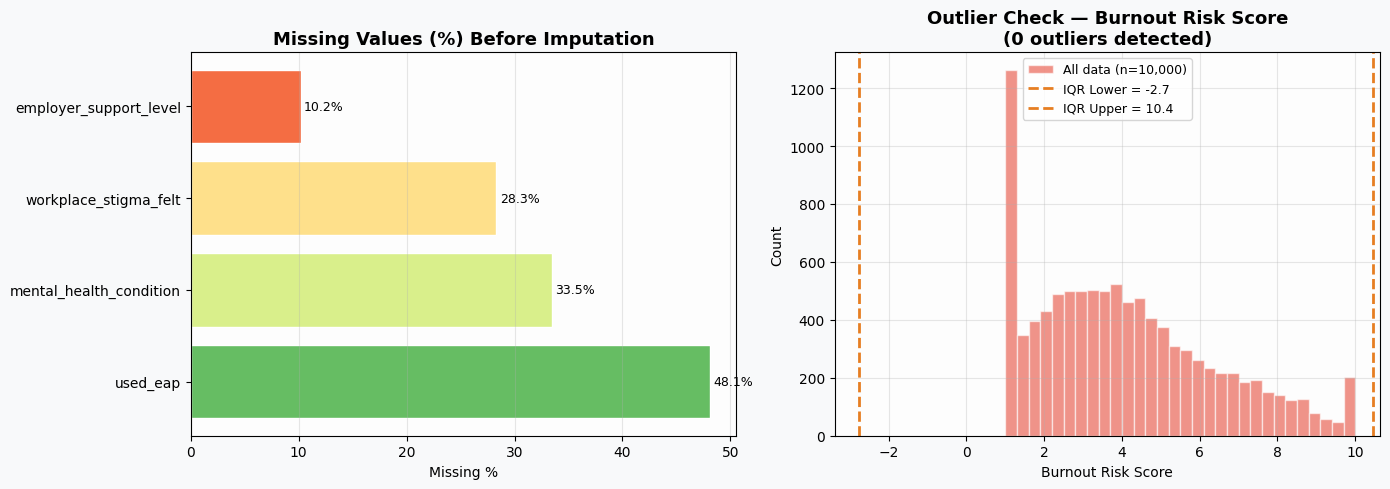


Outlier range: below -2.75 or above 10.45
Outliers found: 0 rows (0.0%) — no removal needed (normal range)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#f8f9fa')

# Missing values bar chart (before cleaning)
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
colors_m = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(missing)))
axes[0].barh(missing.index, missing.values / len(df) * 100,
             color=colors_m, edgecolor='white')
axes[0].set_title('Missing Values (%) Before Imputation',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Missing %')
for i, v in enumerate(missing.values / len(df) * 100):
    axes[0].text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=9)
axes[0].set_facecolor('#fdfdfd'); axes[0].grid(axis='x', alpha=0.3)

# Burnout distribution before vs after outlier check
q1, q3 = df[TARGET].quantile(0.25), df[TARGET].quantile(0.75)
iqr     = q3 - q1
lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
outliers = df[(df[TARGET] < lower) | (df[TARGET] > upper)]

axes[1].hist(df[TARGET], bins=30, color='#e74c3c', alpha=0.6,
             edgecolor='white', label=f'All data (n={len(df):,})')
axes[1].axvline(lower, color='#e67e22', lw=2, linestyle='--', label=f'IQR Lower = {lower:.1f}')
axes[1].axvline(upper, color='#e67e22', lw=2, linestyle='--', label=f'IQR Upper = {upper:.1f}')
axes[1].set_title(f'Outlier Check — Burnout Risk Score\n({len(outliers)} outliers detected)',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Burnout Risk Score'); axes[1].set_ylabel('Count')
axes[1].legend(fontsize=9); axes[1].set_facecolor('#fdfdfd'); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()
print(f"\nOutlier range: below {lower:.2f} or above {upper:.2f}")
print(f"Outliers found: {len(outliers)} rows ({len(outliers)/len(df)*100:.1f}%) — no removal needed (normal range)")

### Encode categorical columns for correlation

Pearson correlation only works on numeric data, so we encode:
- **Ordinal** columns with meaningful order (e.g. stress level: Very Low → 1, Very Severe → 5)
- **Binary** columns as 0 / 1
- **Nominal** columns with LabelEncoder (no natural order — treat with care in modelling)


In [ ]:
df_enc = df.copy()
df_enc.drop(columns=['record_id'], inplace=True)

# ── Ordinal mappings (order matters) ──────────────────────────────────────────
ordinal_maps = {
    'stress_level': {
        'Very Low': 1, 'Low': 2, 'Moderate': 3, 'High': 4, 'Very Severe': 5
    },
    'intention_to_leave': {
        'Very Unlikely': 1, 'Unlikely': 2, 'Neutral': 3, 'Likely': 4, 'Very Likely': 5
    },
    'employer_support_level': {
        'Poor': 1, 'Average': 2, 'Good': 3, 'Excellent': 4
    },
    'workplace_stigma_felt': {
        'None': 1, 'Mild': 2, 'Moderate': 3, 'Severe': 4
    },
    'company_size': {
        'Small (<50)': 1, 'Medium (51-200)': 2,
        'Medium (201-1000)': 3, 'Large (1001-5000)': 4, 'Enterprise (5001+)': 5
    },
}
for col, mapping in ordinal_maps.items():
    df_enc[col] = df_enc[col].map(mapping)

# ── Binary mappings ────────────────────────────────────────────────────────────
binary_maps = {
    'has_diagnosis':               {'No': 0, 'Yes': 1},
    'mental_health_policy_exists': {'No': 0, 'Partial': 0.5, 'Yes': 1},
    'eap_available':               {'No': 0, 'Yes': 1},
    'used_eap':                    {'No': 0, 'Yes': 1},
}
for col, mapping in binary_maps.items():
    df_enc[col] = df_enc[col].map(mapping)

# ── Nominal: LabelEncode remaining string columns ─────────────────────────────
le = LabelEncoder()
nominal_cols = [c for c in df_enc.columns if df_enc[c].dtype == 'object'
                or str(df_enc[c].dtype) == 'string']
print(f"Nominal columns to label-encode: {nominal_cols}")

for col in nominal_cols:
    df_enc[col] = df_enc[col].fillna('Unknown')
    df_enc[col] = le.fit_transform(df_enc[col].astype(str))

# ── Fill remaining NaN with median ────────────────────────────────────────────
df_enc = df_enc.apply(pd.to_numeric, errors='coerce')
df_enc.fillna(df_enc.median(), inplace=True)

print(f"\nEncoded dataframe shape: {df_enc.shape}")
df_enc.head()


Nominal columns to label-encode: ['country', 'industry', 'job_role', 'employment_type', 'work_model', 'age_group', 'gender', 'mental_health_condition', 'treatment_type', 'remote_work_preference']

Encoded dataframe shape: (10000, 33)


,year,country,industry,job_role,employment_type,work_model,company_size,age_group,gender,years_of_experience,...,mental_health_policy_exists,eap_available,used_eap,workplace_stigma_felt,manager_support_score,team_collaboration_score,intention_to_leave,remote_work_preference,exercise_days_per_week,sleep_hours_per_night
0,2024,15,4,10,0,1,4.0,0,1,0,...,1.0,1,0.0,3.0,9.9,9.6,4,1,7,7.1
1,2023,0,2,18,2,1,3.0,3,1,19,...,0.5,1,0.0,4.0,4.1,5.2,2,0,4,6.4
2,2023,2,13,11,2,0,3.0,3,1,19,...,1.0,1,1.0,3.0,9.0,5.9,1,1,3,7.3
3,2020,1,6,12,2,0,3.0,2,1,12,...,1.0,0,0.0,4.0,3.6,9.2,3,2,2,6.1
4,2020,19,3,10,2,1,3.0,1,2,5,...,0.5,1,0.0,3.0,3.8,7.8,2,0,2,7.5


### Compute Pearson correlation matrix

In [ ]:
corr = df_enc.corr()
print(f"Correlation matrix shape: {corr.shape}")


Correlation matrix shape: (33, 33)


### Correlation Heatmap

- 🟠 **Orange dashed border** = Primary target: `burnout_risk_score`  
- 🔵 **Blue dashed border** = Secondary target: `stress_level`  
- Right panel shows the bar chart of all features correlated with the primary target.


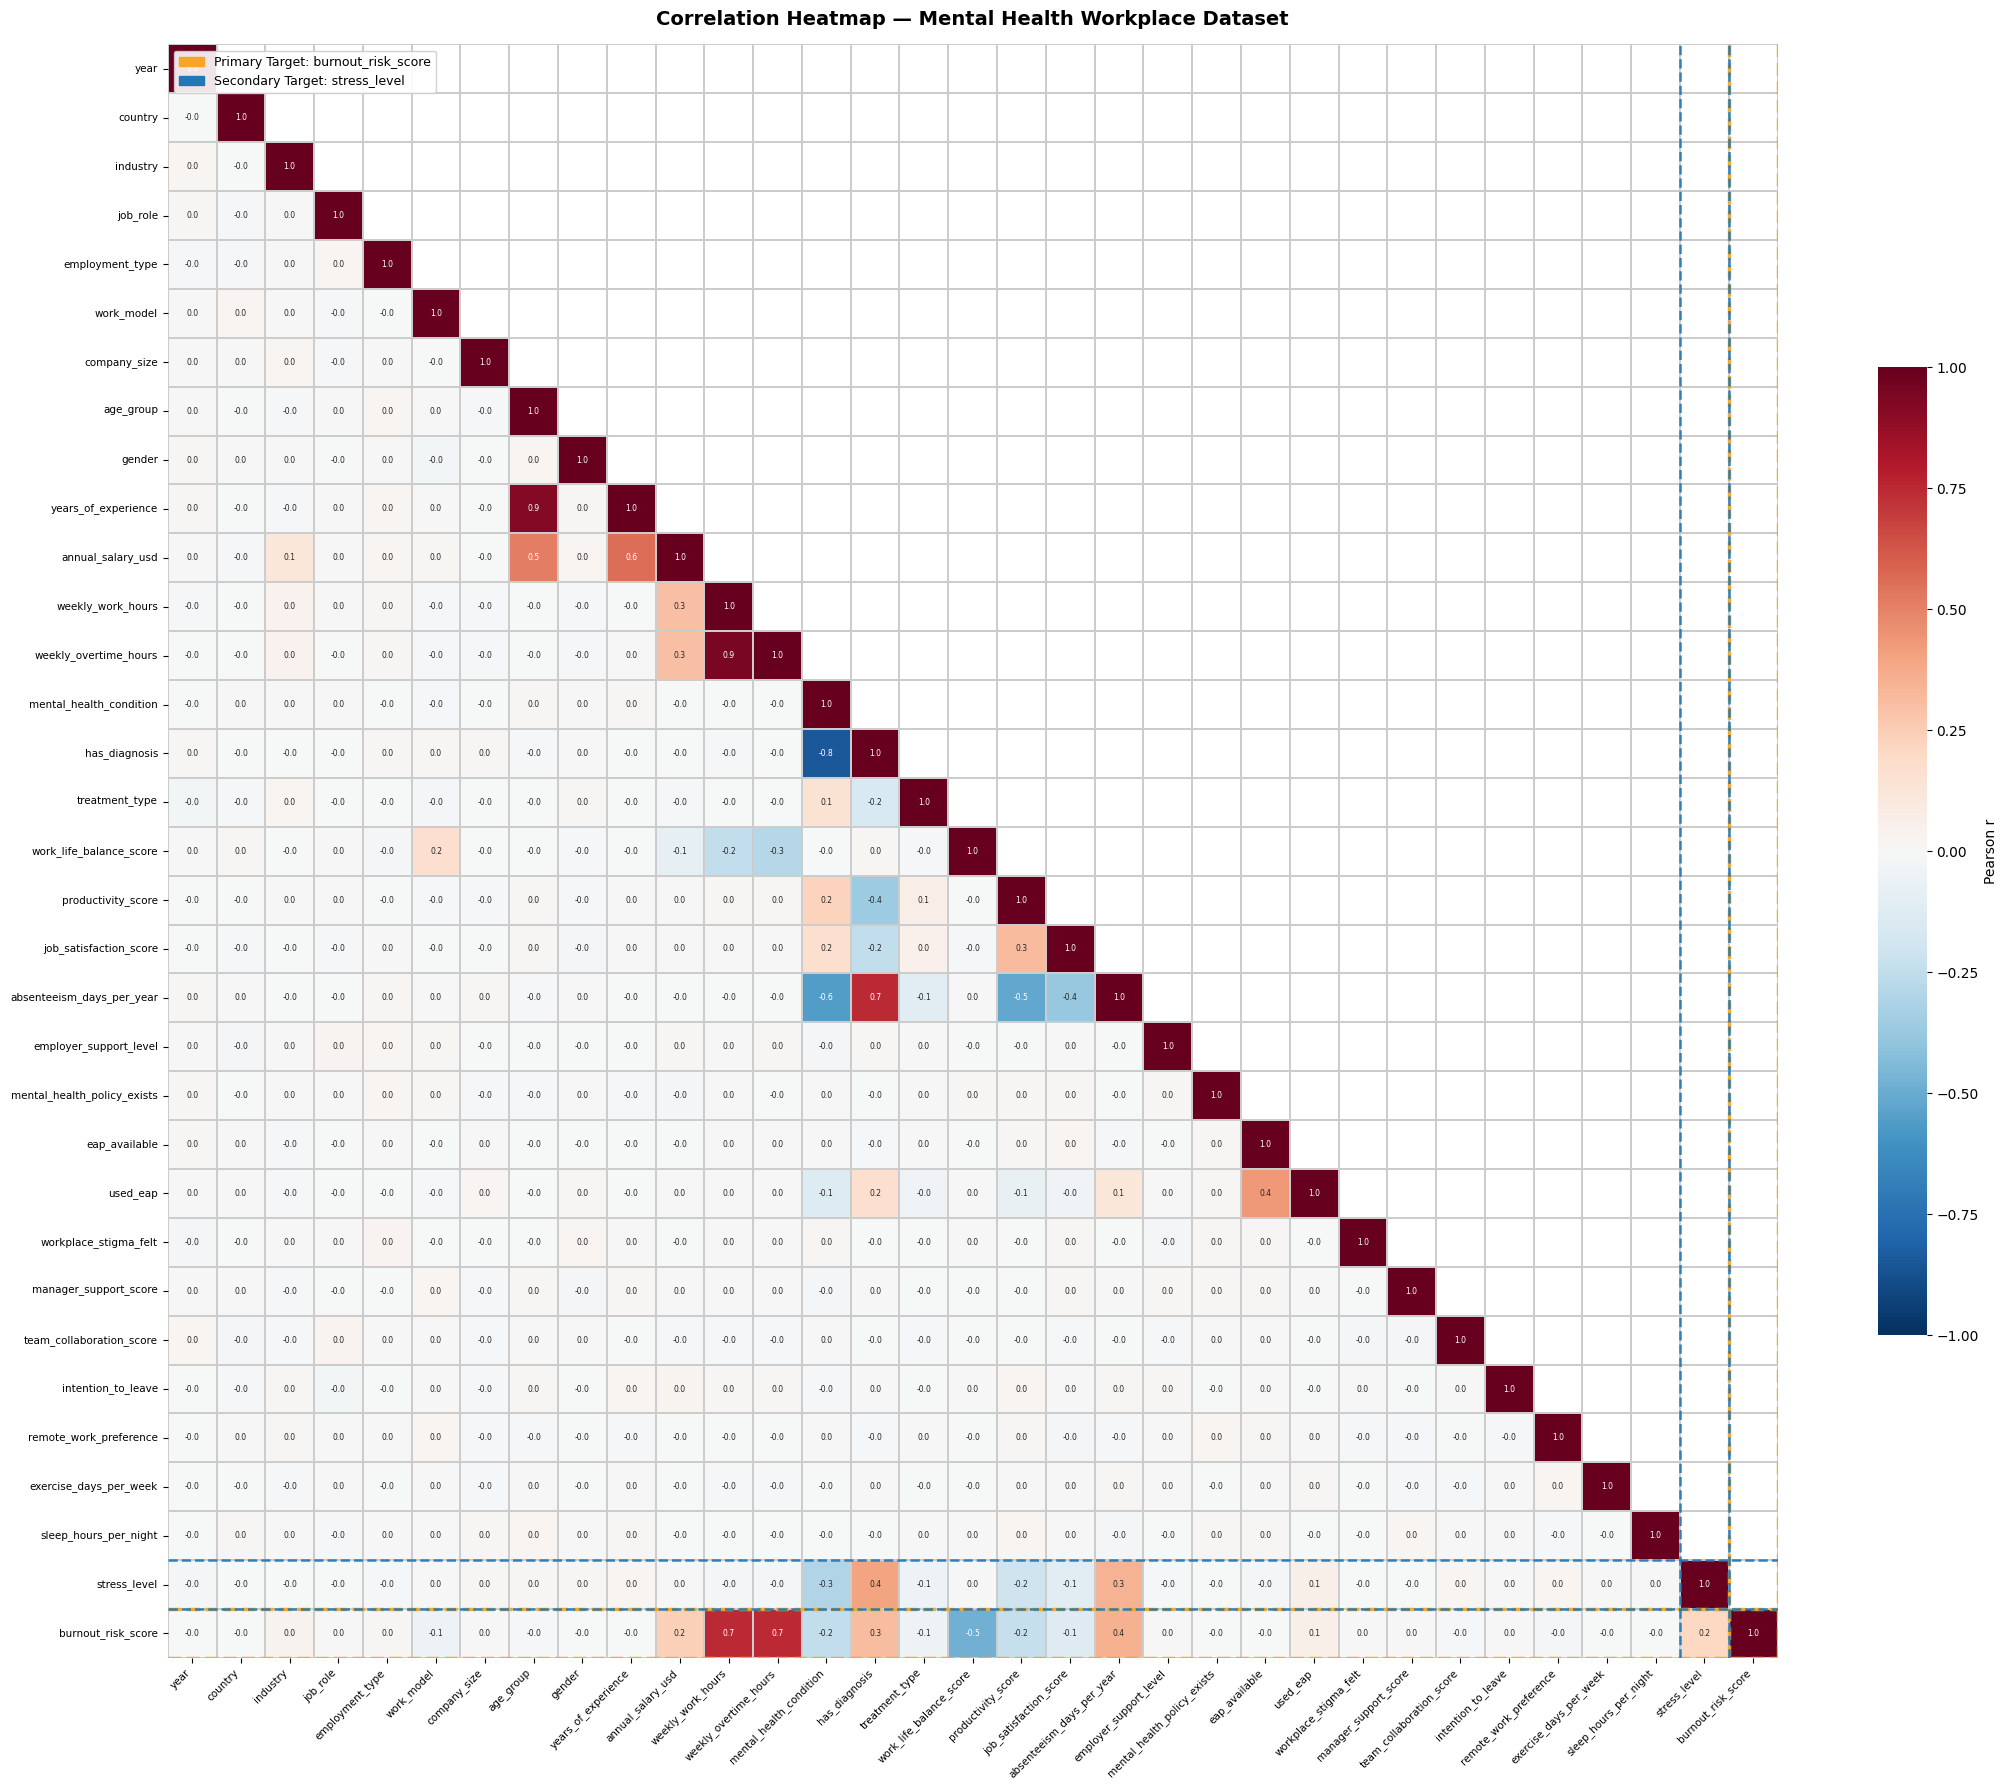

In [ ]:
# ── Reorder columns: targets go LAST ──────────────────────────────────────────
targets = [SECONDARY_TARGET, TARGET]      # secondary first, primary last
feature_cols = [c for c in df_enc.columns if c not in targets]
ordered_cols = feature_cols + targets     # features ... stress_level ... burnout_risk_score

df_enc = df_enc[ordered_cols]

# ── Correlation matrix ─────────────────────────────────────────────────────────
corr = df_enc.corr()
cols_list = corr.columns.tolist()

# Upper triangle mask (so targets at the end are fully visible as the last ROW)
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True   # mask above diagonal only

fig, ax = plt.subplots(figsize=(22, 18))

sns.heatmap(
    corr,
    mask=mask,
    ax=ax,
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    annot=True,
    fmt='.1f',
    annot_kws={'size': 5.5},
    linewidths=0.3,
    linecolor='#cccccc',
    cbar_kws={'shrink': 0.6, 'label': 'Pearson r'},
)

ax.set_title('Correlation Heatmap — Mental Health Workplace Dataset',
             fontsize=14, fontweight='bold', pad=14)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=7.5)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=7.5)

# ── Highlight target rows ──────────────────────────────────────────────────────
for target, color, lw in [(TARGET, '#f5a623', 2.5), (SECONDARY_TARGET, '#1f77b4', 1.8)]:
    idx = cols_list.index(target)
    ax.axhline(y=idx,     color=color, lw=lw, linestyle='--', alpha=0.9)
    ax.axhline(y=idx + 1, color=color, lw=lw, linestyle='--', alpha=0.9)
    ax.axvline(x=idx,     color=color, lw=lw, linestyle='--', alpha=0.9)
    ax.axvline(x=idx + 1, color=color, lw=lw, linestyle='--', alpha=0.9)

patches = [
    mpatches.Patch(color='#f5a623', label=f'Primary Target: {TARGET}'),
    mpatches.Patch(color='#1f77b4', label=f'Secondary Target: {SECONDARY_TARGET}'),
]
ax.legend(handles=patches, loc='upper left', fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.show()

### Top correlations with the primary target

In [ ]:
print(f"{'='*55}")
print(f"Top correlations with PRIMARY target: {TARGET}")
print('='*55)

top = corr[TARGET].drop(TARGET).abs().sort_values(ascending=False).head(15)
results = []
for feat, abs_val in top.items():
    raw_val = corr[TARGET][feat]
    direction = 'Positive' if raw_val > 0 else 'Negative'
    results.append({'Feature': feat, 'Pearson r': round(raw_val, 4), 'Direction': direction})

pd.DataFrame(results)


Top correlations with PRIMARY target: burnout_risk_score


,Feature,Pearson r,Direction
0,weekly_work_hours,0.7472,Positive
1,weekly_overtime_hours,0.7469,Positive
2,work_life_balance_score,-0.4830,Negative
3,absenteeism_days_per_year,0.3549,Positive
4,has_diagnosis,0.3092,Positive
5,mental_health_condition,-0.2435,Negative
6,annual_salary_usd,0.2407,Positive
7,productivity_score,-0.2391,Negative
8,stress_level,0.2085,Positive
9,job_satisfaction_score,-0.1311,Negative


## Top Feature Relationships

/tmp/ipykernel_1022/4049340230.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(stress_order, rotation=15)


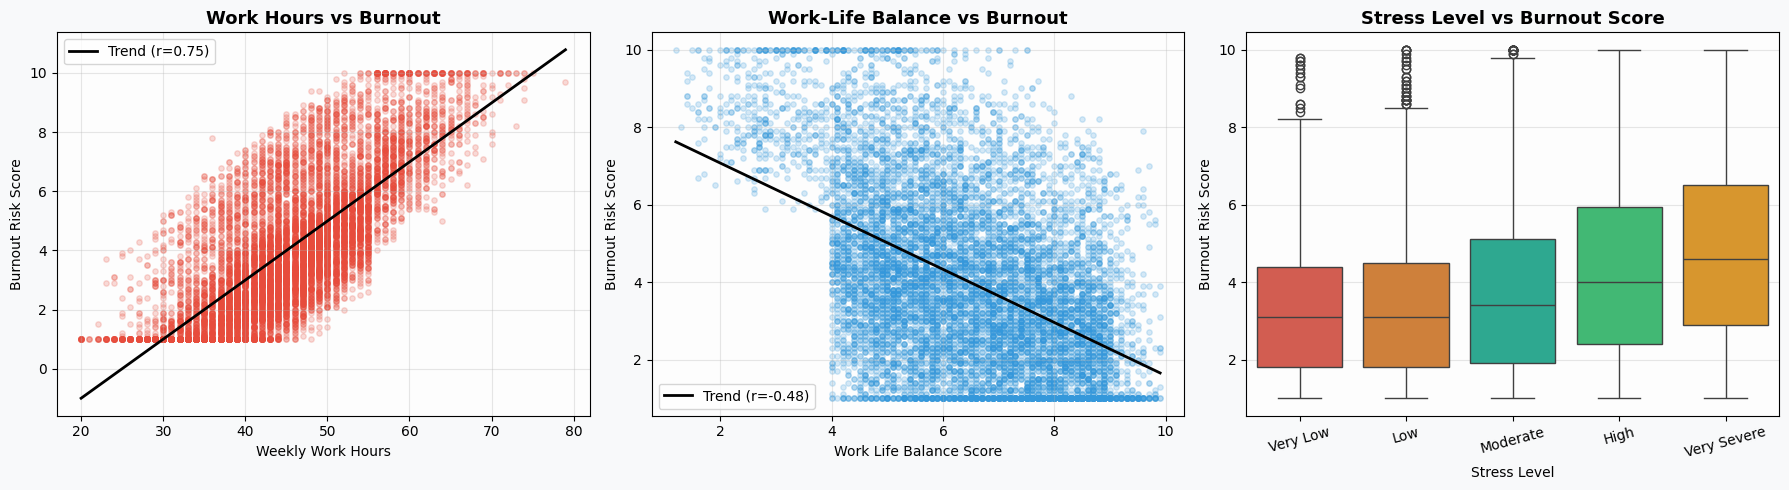

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#f8f9fa')

# Scatter: weekly_work_hours vs burnout
axes[0].scatter(df['weekly_work_hours'], df[TARGET],
                alpha=0.2, color='#e74c3c', s=15)
m, b = np.polyfit(df['weekly_work_hours'].dropna(),
                  df.loc[df['weekly_work_hours'].notna(), TARGET], 1)
x_line = np.linspace(df['weekly_work_hours'].min(), df['weekly_work_hours'].max(), 100)
axes[0].plot(x_line, m*x_line+b, color='black', lw=2, label=f'Trend (r={df["weekly_work_hours"].corr(df[TARGET]):.2f})')
axes[0].set_title('Work Hours vs Burnout', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Weekly Work Hours'); axes[0].set_ylabel('Burnout Risk Score')
axes[0].legend(); axes[0].set_facecolor('#fdfdfd'); axes[0].grid(alpha=0.3)

# Scatter: work_life_balance_score vs burnout
axes[1].scatter(df['work_life_balance_score'], df[TARGET],
                alpha=0.2, color='#3498db', s=15)
m2, b2 = np.polyfit(df['work_life_balance_score'].dropna(),
                    df.loc[df['work_life_balance_score'].notna(), TARGET], 1)
x2 = np.linspace(df['work_life_balance_score'].min(), df['work_life_balance_score'].max(), 100)
axes[1].plot(x2, m2*x2+b2, color='black', lw=2,
             label=f'Trend (r={df["work_life_balance_score"].corr(df[TARGET]):.2f})')
axes[1].set_title('Work-Life Balance vs Burnout', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Work Life Balance Score'); axes[1].set_ylabel('Burnout Risk Score')
axes[1].legend(); axes[1].set_facecolor('#fdfdfd'); axes[1].grid(alpha=0.3)

# Boxplot: stress_level vs burnout
stress_order = ['Very Low','Low','Moderate','High','Very Severe']
palette3 = ['#2ecc71','#1abc9c','#f39c12','#e67e22','#e74c3c']
sns.boxplot(data=df, x='stress_level', y=TARGET,  hue='stress_level',
            legend=False,order=stress_order, palette=palette3, ax=axes[2])
axes[2].set_title('Stress Level vs Burnout Score', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Stress Level'); axes[2].set_ylabel('Burnout Risk Score')
axes[2].set_xticklabels(stress_order, rotation=15)
axes[2].set_facecolor('#fdfdfd'); axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X = df_enc.drop(columns=[TARGET])
y = df_enc[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

rf = RandomForestRegressor(n_estimators=200, max_depth=15,
                            random_state=42, n_jobs=-1)
rf.fit(X_train_s, y_train)
y_pred = rf.predict(X_test_s)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print("=" * 40)
print("   Random Forest Regressor Results")
print("=" * 40)
print(f"  MAE  (Mean Abs Error) : {mae:.4f}")
print(f"  RMSE (Root MSE)       : {rmse:.4f}")
print(f"  R²   (R-squared)      : {r2:.4f}")
print("=" * 40)

   Random Forest Regressor Results
  MAE  (Mean Abs Error) : 0.4109
  RMSE (Root MSE)       : 0.5401
  R²   (R-squared)      : 0.9440


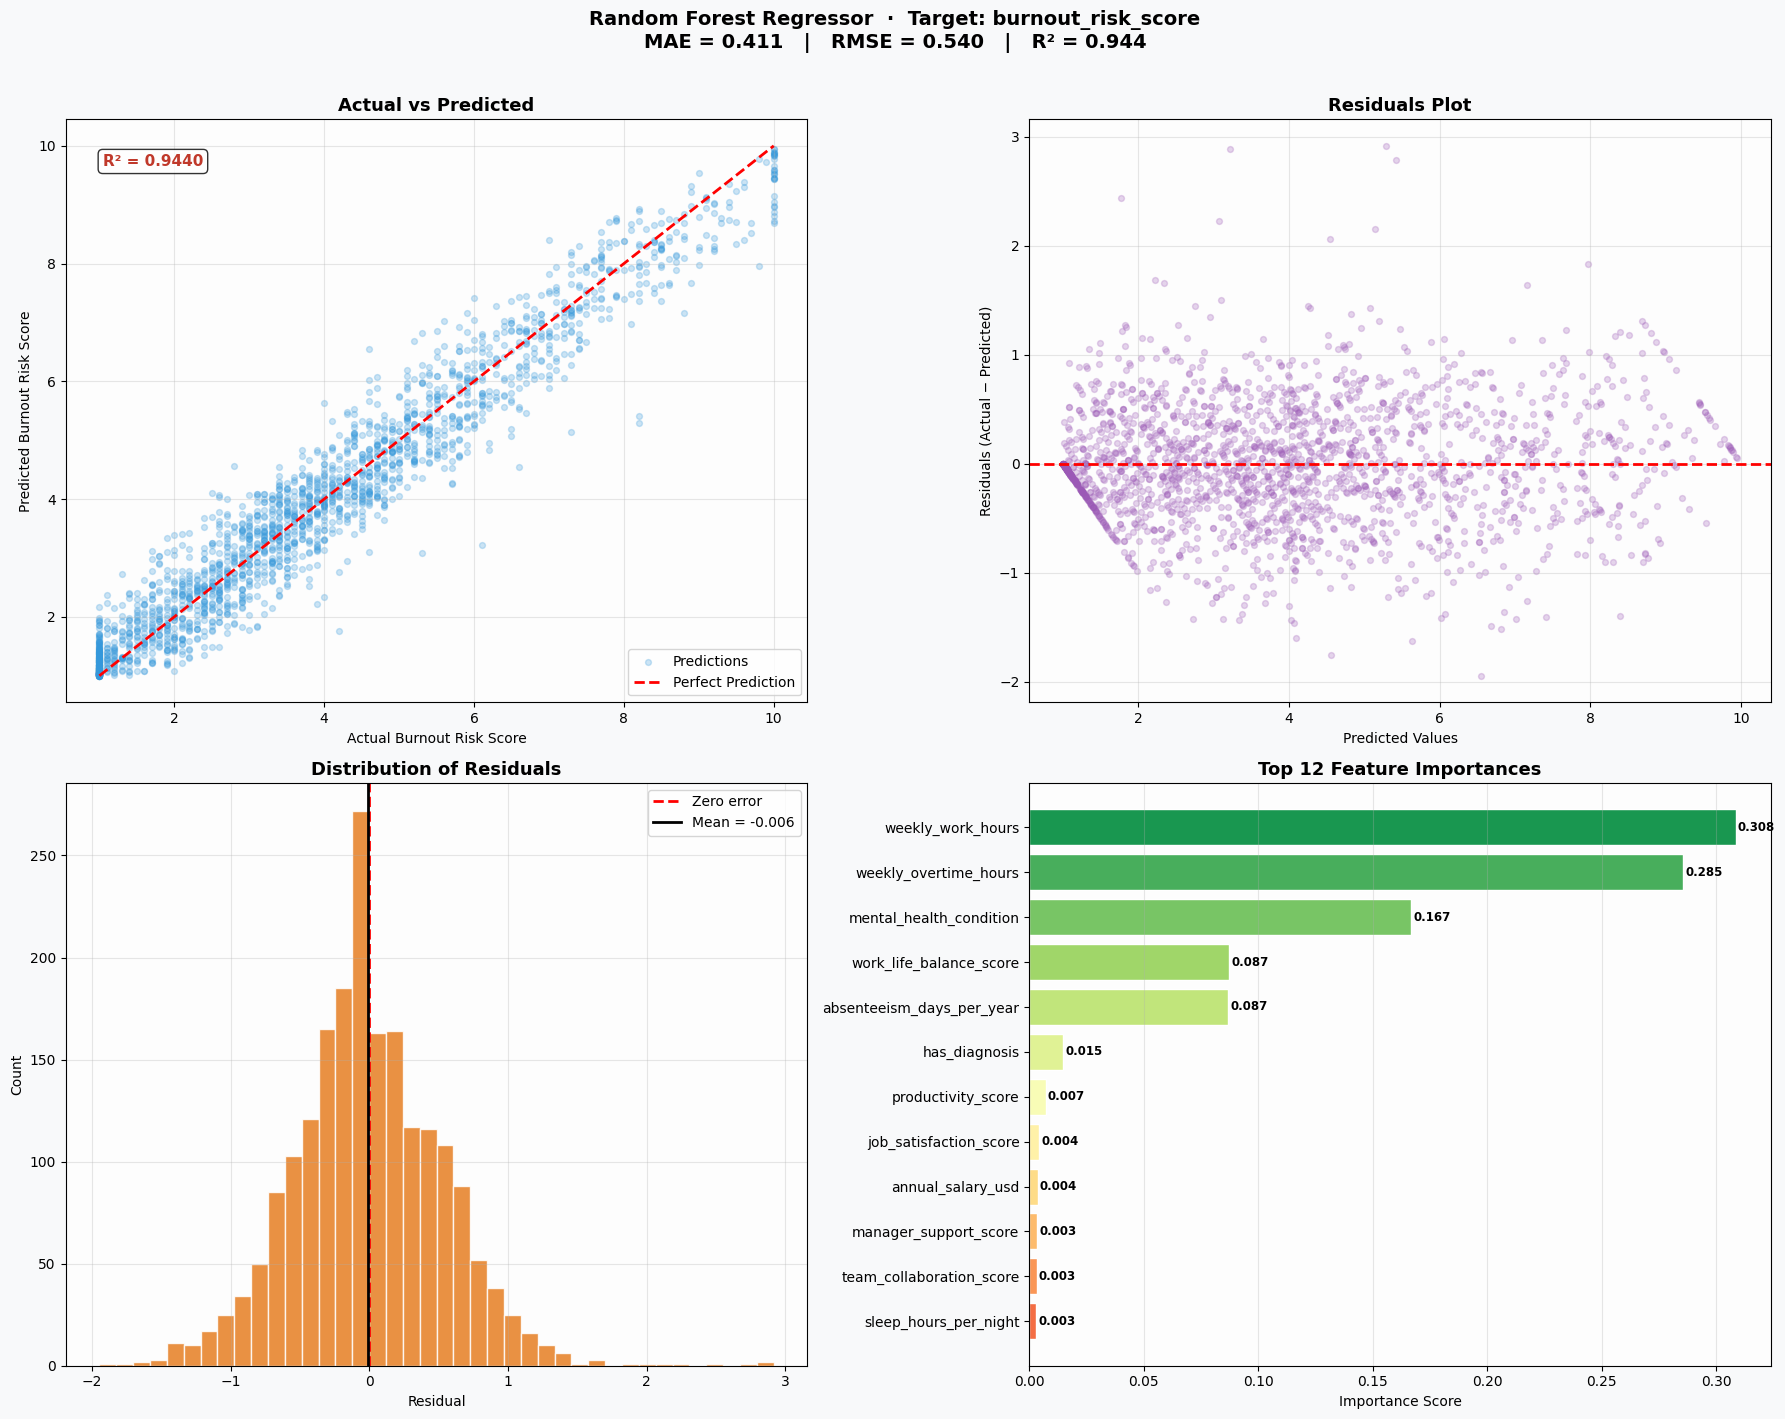

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.patch.set_facecolor('#f8f9fa')

# ── Plot 1: Actual vs Predicted ───────────────────────────────────────────────
ax1 = axes[0, 0]
ax1.scatter(y_test, y_pred, alpha=0.25, color='#3498db', s=18, label='Predictions')
min_v, max_v = y_test.min(), y_test.max()
ax1.plot([min_v, max_v], [min_v, max_v], 'r--', lw=2, label='Perfect Prediction')
ax1.set_title('Actual vs Predicted', fontsize=13, fontweight='bold')
ax1.set_xlabel('Actual Burnout Risk Score')
ax1.set_ylabel('Predicted Burnout Risk Score')
ax1.legend(); ax1.set_facecolor('#fdfdfd'); ax1.grid(alpha=0.3)
ax1.text(0.05, 0.92, f'R² = {r2:.4f}', transform=ax1.transAxes,
         fontsize=11, color='#c0392b', fontweight='bold',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# ── Plot 2: Residuals ─────────────────────────────────────────────────────────
ax2 = axes[0, 1]
residuals = y_test - y_pred
ax2.scatter(y_pred, residuals, alpha=0.25, color='#9b59b6', s=18)
ax2.axhline(0, color='red', lw=2, linestyle='--')
ax2.set_title('Residuals Plot', fontsize=13, fontweight='bold')
ax2.set_xlabel('Predicted Values')
ax2.set_ylabel('Residuals (Actual − Predicted)')
ax2.set_facecolor('#fdfdfd'); ax2.grid(alpha=0.3)

# ── Plot 3: Residuals Distribution ───────────────────────────────────────────
ax3 = axes[1, 0]
ax3.hist(residuals, bins=40, color='#e67e22', edgecolor='white', alpha=0.85)
ax3.axvline(0, color='red', lw=2, linestyle='--', label='Zero error')
ax3.axvline(residuals.mean(), color='black', lw=2, linestyle='-',
            label=f'Mean = {residuals.mean():.3f}')
ax3.set_title('Distribution of Residuals', fontsize=13, fontweight='bold')
ax3.set_xlabel('Residual'); ax3.set_ylabel('Count')
ax3.legend(); ax3.set_facecolor('#fdfdfd'); ax3.grid(alpha=0.3)

# ── Plot 4: Feature Importance (Top 12) ──────────────────────────────────────
ax4 = axes[1, 1]
feat_imp = pd.Series(rf.feature_importances_, index=X.columns)
top12    = feat_imp.sort_values(ascending=True).tail(12)
colors_f = plt.cm.RdYlGn(np.linspace(0.2, 0.9, 12))
bars = ax4.barh(top12.index, top12.values, color=colors_f, edgecolor='white')
for bar, val in zip(bars, top12.values):
    ax4.text(val + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=8.5, fontweight='bold')
ax4.set_title('Top 12 Feature Importances', fontsize=13, fontweight='bold')
ax4.set_xlabel('Importance Score')
ax4.set_facecolor('#fdfdfd'); ax4.grid(axis='x', alpha=0.3)

fig.suptitle(f'Random Forest Regressor  ·  Target: burnout_risk_score\n'
             f'MAE = {mae:.3f}   |   RMSE = {rmse:.3f}   |   R² = {r2:.3f}',
             fontsize=14, fontweight='bold', y=1.01)

plt.tight_layout()
plt.show()